# Predicting ICU Mortality Using Machine Learning

**Dataset:** MIMIC-III Critical Care Database  
**Target Variable:** `ExpiredHospital` (In-hospital mortality)

 ## Project Purpose 
 This Project demonstrates an end-to-end machine learning workflow for predicting mortality risk among ICU patients using structured clinical data.     The goal is to identify patterns in patient records that may indicate higher risk of in-hospital mortality


 ## What This Notebook Shows
 
 This notebook is designed as a portfolio project reflecting real-world healthcare machine learning workflows.

 The notebook includes key stages such as exploratory data analysis (EDA), data preprocessing, feature engineering, model training, and evaluation.

 In addition to predictive modeling, the project focuses on interpreting clinically relevant features to provide meaningful and transparent insights,   which is essential for real-world healthcare applications


## Dataset Information

This analysis uses an aggregated ICU clinical dataset derived from MIMIC-III (EHR)electronic health records.

The full dataset is not included in this repository.

To run this notebook locally:

- Download the dataset from Kaggle  
- Place `mimic3c.csv` in the project root directory

Dataset Source:  
https://www.kaggle.com/datasets/drscarlat/mimic3c


### Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
os.makedirs("images", exist_ok=True)

In [23]:
df = pd.read_csv("mimic3c.csv")
df.head()

,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,...,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
0,100001,F,35,6.17,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,...,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89,2
1,100003,M,59,4.04,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,...,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71,2
2,100006,F,48,12.04,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,...,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00,4
3,100007,F,73,7.29,EMERGENCY,EMERGENCY ROOM ADMIT,BOWEL OBSTRUCTION,Private,JEWISH,MARRIED,...,0.69,0.17,9.05,11.52,0.00,0.96,526.06,0,603.05,2
4,100009,M,60,4.88,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,CORONARY ARTERY DISEASE,Private,CATHOLIC,MARRIED,...,0.61,0.34,16.19,25.00,2.87,2.05,554.92,0,679.84,2


## Dataset Overview

The dataset contains structured clinical variables collected from ICU patients, including demographic information, laboratory results, and clinical activity indicators.


## Exploratory Data Analysis (EDA) 

This section explores the structure, distributions, and relationships within the dataset to understand patterns relevant to in-hospital mortality.


###  Basic Structure

In [24]:
#  Dataframe info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58976 entries, 0 to 58975
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hadm_id           58976 non-null  int64  
 1   gender            58976 non-null  object 
 2   age               58976 non-null  int64  
 3   LOSdays           58976 non-null  float64
 4   admit_type        58976 non-null  object 
 5   admit_location    58976 non-null  object 
 6   AdmitDiagnosis    58951 non-null  object 
 7   insurance         58976 non-null  object 
 8   religion          58518 non-null  object 
 9   marital_status    48848 non-null  object 
 10  ethnicity         58976 non-null  object 
 11  NumCallouts       58976 non-null  float64
 12  NumDiagnosis      58976 non-null  float64
 13  NumProcs          58976 non-null  float64
 14  AdmitProcedure    58976 non-null  object 
 15  NumCPTevents      58976 non-null  float64
 16  NumInput          58976 non-null  float6

In [25]:
### Summary statistics for numeric columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
hadm_id,58976.0,149970.809584,28883.095213,100001.0,124952.7500,149989.500,174966.5000,199999.00
age,58976.0,53.005884,26.028120,0.0,43.0000,59.000,73.0000,89.00
LOSdays,58976.0,10.114955,12.456231,0.0,3.7100,6.460,11.7900,294.63
NumCallouts,58976.0,0.099374,0.163437,0.0,0.0000,0.000,0.1600,4.76
NumDiagnosis,58976.0,2.675960,8.265590,0.0,0.8200,1.410,2.4000,450.00
NumProcs,58976.0,0.785599,3.558090,0.0,0.2100,0.420,0.7100,275.00
NumCPTevents,58976.0,1.074118,2.027148,0.0,0.0000,0.970,1.5600,225.00
NumInput,58976.0,30.379017,62.430163,0.0,4.8500,13.990,34.3600,6825.00
NumLabs,58976.0,46.421124,76.061561,0.0,26.9800,38.520,50.8600,5175.00
NumMicroLabs,58976.0,1.219913,4.236693,0.0,0.1600,0.510,1.3500,375.00


### Observation: 
The dataset reflects typical EHR-derived tabular data, containing a mix of numeric and categorical variables with varying levels of missingness — a common characteristic of real ICU data.

### Target Variable: In-Hospital Mortality

The target variable `ExpiredHospital` represents patient outcome:

- **0 → Survived**
- **1 → Died**

Understanding the distribution of this outcome is essential before modeling, particularly in healthcare contexts where class imbalance is common.


### Mortality Outcome Distribution


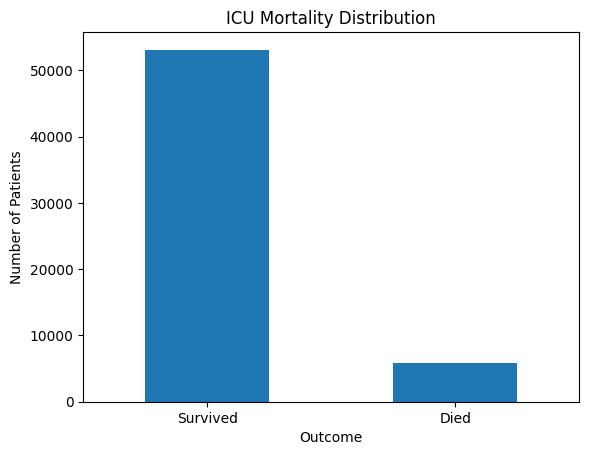

In [26]:
mortality_counts = df["ExpiredHospital"].value_counts().sort_index()

mortality_counts.plot(kind="bar")
plt.title("ICU Mortality Distribution")
plt.xticks([0, 1], ["Survived", "Died"], rotation=0)
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.savefig("images/mortality_distribution.png", 
            dpi=150, 
            bbox_inches='tight',
            format='png')
plt.show()


### Observation: 
Mortality cases represent a smaller proportion of the dataset, indicating class imbalance. As a result, model evaluation must go beyond accuracy and emphasize metrics that capture performance on the minority (high-risk) class.


### Missing Values -
We will calculate how much data is missing in each column and visualize it. This helps decide how to handle missing values later

In [27]:
# 4.1 Missing value percentage per column
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)


marital_status      17.173087
religion             0.776587
AdmitDiagnosis       0.042390
hadm_id              0.000000
LOSdays              0.000000
age                  0.000000
gender               0.000000
admit_type           0.000000
insurance            0.000000
admit_location       0.000000
ethnicity            0.000000
NumCallouts          0.000000
NumDiagnosis         0.000000
NumProcs             0.000000
AdmitProcedure       0.000000
NumCPTevents         0.000000
NumInput             0.000000
NumLabs              0.000000
NumMicroLabs         0.000000
NumNotes             0.000000
NumOutput            0.000000
NumRx                0.000000
NumProcEvents        0.000000
NumTransfers         0.000000
NumChartEvents       0.000000
ExpiredHospital      0.000000
TotalNumInteract     0.000000
LOSgroupNum          0.000000
dtype: float64

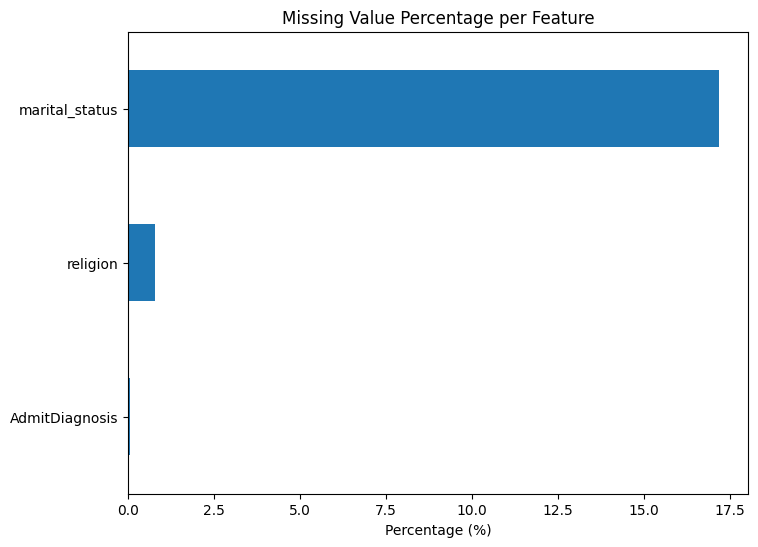

In [28]:
# 4.2 Missing value percentage bar chart

missing_percent[missing_percent > 0].plot(kind='barh', figsize=(8,6))
plt.title("Missing Value Percentage per Feature")
plt.xlabel("Percentage (%)")
plt.show()


### Observation
Here we identify which columns have missing values and how much.
Next we’ll decide: drop (too much missing) vs impute (reasonable missing).

### 5. Identify Numeric and Categorical Features – What We Are Going To Do
We will find which columns are numeric and which are categorical (text), because they need different handling.

In [29]:
# 5. Identify numeric and categorical columns

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

len(cat_cols), len(num_cols)
cat_cols, num_cols [:10]  # show some examples


(['gender',
  'admit_type',
  'admit_location',
  'AdmitDiagnosis',
  'insurance',
  'religion',
  'marital_status',
  'ethnicity',
  'AdmitProcedure'],
 ['hadm_id',
  'age',
  'LOSdays',
  'NumCallouts',
  'NumDiagnosis',
  'NumProcs',
  'NumCPTevents',
  'NumInput',
  'NumLabs',
  'NumMicroLabs'])

### Observation
We separate categorical vs numeric columns because we treat them differently.
Categorical → fill + one‑hot encode
Numeric → fill + scale

### 6. Numerical Features vs Mortality

Boxplots are used to compare the distribution of selected numerical features between surviving and non-surviving patients.


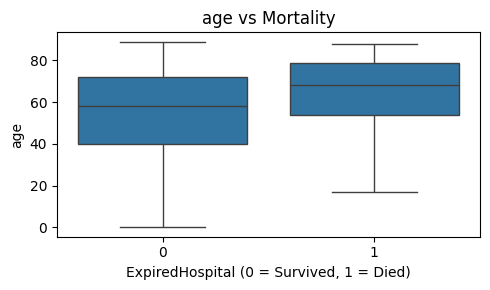

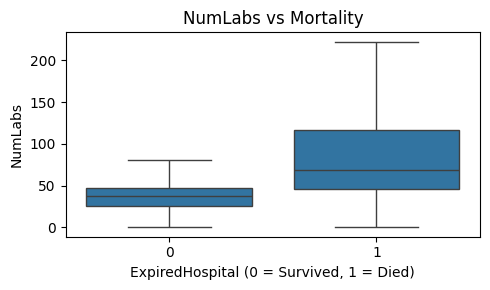

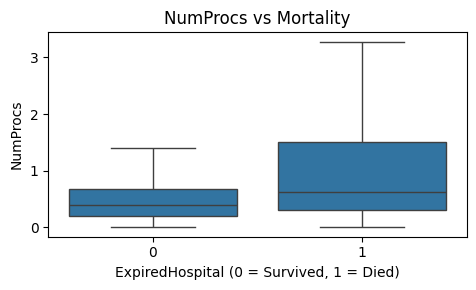

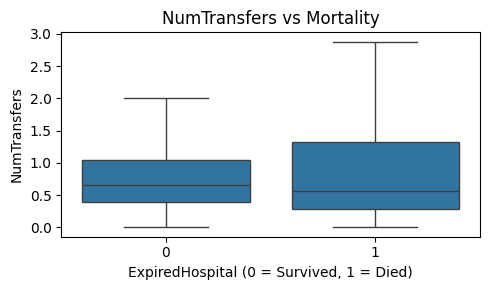

In [30]:
target_col = "ExpiredHospital"
cols_to_plot = [
    "age",
    "NumLabs",
    "NumProcs",
    "NumTransfers",
    
]

for colname in cols_to_plot:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=target_col, y=colname,data=df,showfliers=False)  # hide extreme outliers for visul clarity
    plt.title(f"{colname} vs Mortality")
    plt.xlabel("ExpiredHospital (0 = Survived, 1 = Died)")
    plt.ylabel(colname)
    plt.tight_layout()
    plt.show()

### Observation
Each boxplot shows how a numeric feature differs between:

Patients with 0 in the target (survived)
Patients with 1 in the target (died)
If the two boxes are very different, that feature may be important for predicting mortality.
This is a simple but powerful way to connect features with the clinical outcome.

### 7. Categorical Features vs Mortality

In this section, we analyze how selected categorical features relate to in-hospital mortality. 
By comparing outcome distributions across different categories, we can observe whether certain 
groups show differing survival patterns.


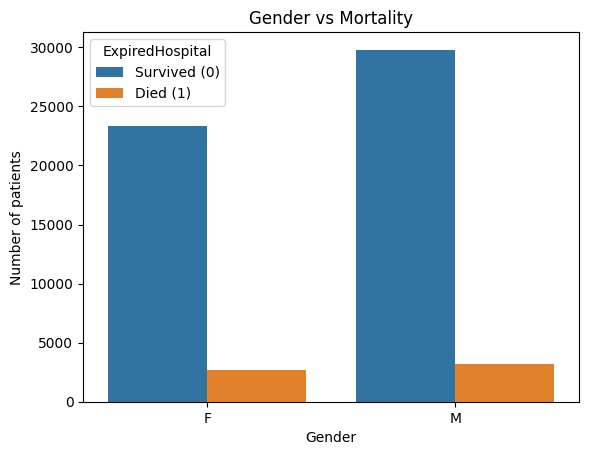

In [31]:
# 7.1 Gender vs Mortality

sns.countplot(x='gender', hue='ExpiredHospital', data=df)
plt.title("Gender vs Mortality")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.legend(title="ExpiredHospital", labels=["Survived (0)", "Died (1)"])
plt.show()

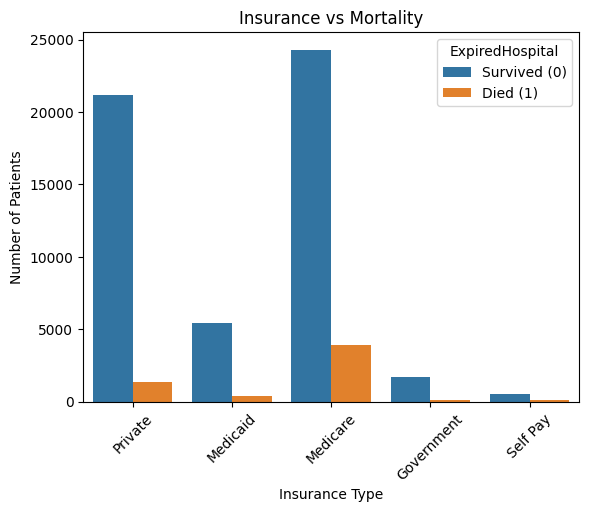

In [32]:
### 7.2 Insurance vs Mortality

sns.countplot(x='insurance', hue='ExpiredHospital', data=df)
plt.title("Insurance vs Mortality")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Patients")
plt.legend(title="ExpiredHospital", labels=["Survived (0)", "Died (1)"])
plt.xticks(rotation=45)
plt.show()


### **Observation:**
- Mortality patterns differ slightly across gender and insurance categories.
- These differences suggest that demographic and healthcare access factors may have an association with in-hospital outcomes.


### 8. Correlation Analysis

A correlation heatmap is used to examine relationships among numerical features and identify potential redundancy.



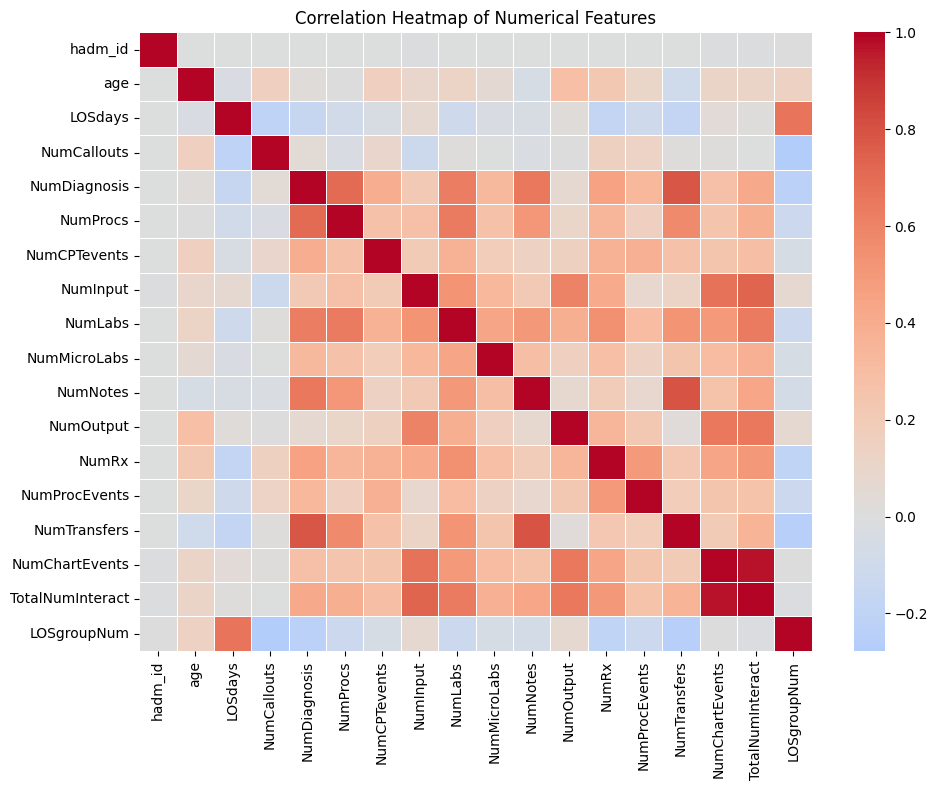

In [33]:
# 8.1 Correlation matrix and heatmap
# Select numerical features only (exclude target)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['ExpiredHospital'], errors='ignore')

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [34]:
# 8.2Correlation of numerical features with target
corr_with_target = df.select_dtypes(include=['int64', 'float64']).corr()['ExpiredHospital']
corr_with_target = corr_with_target.sort_values(ascending=False)

corr_with_target


ExpiredHospital     1.000000
NumInput            0.368530
TotalNumInteract    0.350784
NumChartEvents      0.330790
NumLabs             0.316719
NumRx               0.298553
NumOutput           0.292912
NumCPTevents        0.222236
NumProcEvents       0.206404
NumDiagnosis        0.184477
NumMicroLabs        0.181981
age                 0.157519
NumProcs            0.150200
NumTransfers        0.082643
NumNotes            0.057827
LOSdays            -0.000076
hadm_id            -0.003120
LOSgroupNum        -0.026785
NumCallouts        -0.109290
Name: ExpiredHospital, dtype: float64

### Observation
The correlation heatmap shows how numeric features relate to each other.
The table of correlations with ExpiredHospital shows which features have stronger relationships with mortality.
This helps us understand which clinical variables might be more predictive.

### 9 Multicollinearity Check

Highly correlated numerical features (|correlation| > 0.90) are identified to assess potential redundancy among predictors.


In [35]:
#  Multicollinearity check (correlation > 0.90)

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = upper[upper > 0.90].stack().sort_values(ascending=False)
high_corr_pairs

NumChartEvents  TotalNumInteract    0.974447
dtype: float64

### Observation:
- `NumChartEvents` and `TotalNumInteract` show very high correlation (> 0.90), indicating potential redundancy.
- Feature selection decisions will consider interpretability and model performance.
- In this project, we mainly use tree-based models, which can handle some multicollinearity, so we simply note these pairs and keep the features.


# Data Pre-processing

The following steps prepare the dataset for modeling by removing non-informative features and handling missing values.


### 10. Dropping Identifier and Length-of-stay

We will remove columns that should not be used as input features for mortality prediction




In [36]:
df = df.drop(columns=['LOSdays', 'LOSgroupNum', 'hadm_id'], errors='ignore')
df.head()

,gender,age,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,ethnicity,NumCallouts,...,NumLabs,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract
0,F,35,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,WHITE,0.16,...,43.44,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89
1,M,59,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,WHITE,0.25,...,55.94,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71
2,F,48,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,BLACK/AFRICAN AMERICAN,0.00,...,33.39,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00
3,F,73,EMERGENCY,EMERGENCY ROOM ADMIT,BOWEL OBSTRUCTION,Private,JEWISH,MARRIED,WHITE,0.41,...,32.24,0.69,0.17,9.05,11.52,0.00,0.96,526.06,0,603.05
4,M,60,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,CORONARY ARTERY DISEASE,Private,CATHOLIC,MARRIED,WHITE,0.00,...,50.61,0.61,0.34,16.19,25.00,2.87,2.05,554.92,0,679.84


### Observation:
- Identifier has been removed, leaving a cleaner set of predictors for modeling.
- Length-of-stay related features are excluded as they may reflect information not available at prediction time.



### Define Features (X) and Target (y)

In [37]:
# ExpiredHospital: 1 = Expired, 0 = Alive
y = df["ExpiredHospital"]

X = df.drop(columns=["ExpiredHospital"])


### The target variable is excluded from numeric features to prevent it from being unintentionally scaled during preprocessing.


In [38]:
if "ExpiredHospital" in num_cols:
    num_cols.remove("ExpiredHospital")


### Quick data check
Confirmed feature matrix size and reviewed the in-hospital mortality split
before proceeding to model training.


In [39]:
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())


X shape: (58976, 24)
y distribution:
ExpiredHospital
0    53122
1     5854
Name: count, dtype: int64


### Modeling Strategy

The modeling approach follows a structured workflow:

data preprocessing → feature encoding → train-test split → model training → evaluation

Train-test splitting is performed **before** encoding and scaling to prevent data leakage and ensure reliable model evaluation.

### Train–Test Split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns


### 10. Handle Missing Values – Numeric

In [41]:
# Impute using TRAIN statistics only (prevents leakage)
train_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

In [42]:
# Null check AFTER imputation (train/test)
print("Missing values in X_train (numeric):")
display(X_train[num_cols].isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in X_test (numeric):")
display(X_test[num_cols].isnull().sum().sort_values(ascending=False).head(10))

Missing values in X_train (numeric):


age             0
NumCallouts     0
NumDiagnosis    0
NumProcs        0
NumCPTevents    0
NumInput        0
NumLabs         0
NumMicroLabs    0
NumNotes        0
NumOutput       0
dtype: int64


Missing values in X_test (numeric):


age             0
NumCallouts     0
NumDiagnosis    0
NumProcs        0
NumCPTevents    0
NumInput        0
NumLabs         0
NumMicroLabs    0
NumNotes        0
NumOutput       0
dtype: int64

### **Observation:**
- Numerical features contain no remaining missing values after median imputation.


###  Handle Missing Values – Categorical

In [43]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [44]:
df[cat_cols].isnull().sum()


gender            0
admit_type        0
admit_location    0
AdmitDiagnosis    0
insurance         0
religion          0
marital_status    0
ethnicity         0
AdmitProcedure    0
dtype: int64

### **Observation:**
- All missing values in categorical features have been successfully imputed using the mode.


### Real-World Considerations

- Only admission-time features are used to avoid future information leakage  
- Train-test split is performed before encoding and scaling  
- Interpretability is important in healthcare settings  
- Minimizing false negatives is critical, as missing high-risk patients can have serious consequences

### One-Hot Encoding after split and Feature Name Standardization

Categorical variables are one-hot encoded after the split to keep evaluation independent from training.

The test set is aligned to the training feature space to ensure consistency.

Feature names are standardized to avoid incompatibility with models like XGBoost, which require valid column names.

In [45]:
# One-hot encode categorical columns (train first), then match test to train's columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)


# Keep exactly the same columns (and order) as training
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)


X_train_enc.columns = [str(c).replace('[','_').replace(']','_').replace('<','_').replace('>','_') for c in X_train_enc.columns]
X_test_enc.columns  = [str(c).replace('[','_').replace(']','_').replace('<','_').replace('>','_') for c in X_test_enc.columns]
print("Duplicate columns count:", sum(pd.Index(X_train_enc.columns).duplicated()))




Duplicate columns count: 0


### Column consistency
Test features are reshaped to match training columns so the model receives the same input layout.


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report




In [47]:
def evaluate_model(name, y_true, y_pred, y_score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
    }


## Model Selection Rationale

Three models are evaluated to balance interpretability and predictive performance:

- **Logistic Regression**: Baseline, interpretable linear model  
- **Random Forest**: Captures non-linear relationships and feature interactions  
- **XGBoost**:  High-performance model well-suited for tabular clinical data  

Deep learning models are intentionally excluded, as they often provide limited benefit for structured ICU data while reducing interpretability.


###  Train Three Models
We will train three popular models for tabular healthcare data:

- Random Forest
- XGBoost
- LightGBM

### Logistic Regression is sensitive to feature scale. We scale only continuous numeric columns and keep 0/1 columns unchanged (including one-hot features).

In [48]:
# Copy encoded data
X_train_lr = X_train_enc.copy()
X_test_lr  = X_test_enc.copy()

# Identify numeric columns AFTER encoding
num_cols_lr = X_train_lr.select_dtypes(include=["int64", "float64"]).columns

# Scale numeric columns only
scaler = StandardScaler()
X_train_lr[num_cols_lr] = scaler.fit_transform(X_train_lr[num_cols_lr])
X_test_lr[num_cols_lr]  = scaler.transform(X_test_lr[num_cols_lr])

# Train Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_lr, y_train)

# Predict
lr_pred  = lr.predict(X_test_lr)
lr_score = lr.decision_function(X_test_lr)

lr_metrics = evaluate_model("Logistic Regression (Baseline)", y_test, lr_pred, lr_score)
lr_metrics


{'Model': 'Logistic Regression (Baseline)',
 'Accuracy': 0.9348084096303831,
 'Precision': 0.8045454545454546,
 'Recall': 0.45345858240819814,
 'F1': 0.5800109229929,
 'ROC_AUC': 0.9093597227106043}

 **Observation:**
Logistic Regression provides a transparent baseline. While performance may be limited by linear assumptions, it establishes a clinical reference point for recall and discrimination.


### Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_enc, y_train)

rf_pred  = rf.predict(X_test_enc)
rf_score = rf.predict_proba(X_test_enc)[:, 1]

rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_score)
rf_metrics


{'Model': 'Random Forest',
 'Accuracy': 0.9376907426246185,
 'Precision': 0.8811188811188811,
 'Recall': 0.430401366353544,
 'F1': 0.5783132530120482,
 'ROC_AUC': 0.9292204752097252}

**Observation:** Random Forest improves non-linear pattern capture but may introduce instability depending on depth and feature sparsity. Errors during tuning indicate sensitivity to parameter choices.


### XGBoost

In [50]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(X_train_enc, y_train)

# Predict (MUST define these before evaluate_model)
xgb_pred  = xgb_model.predict(X_test_enc)
xgb_score = xgb_model.predict_proba(X_test_enc)[:, 1]

# Evaluate + display
xgb_metrics = evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)
xgb_metrics


{'Model': 'XGBoost',
 'Accuracy': 0.937605968124788,
 'Precision': 0.8436018957345972,
 'Recall': 0.4560204953031597,
 'F1': 0.5920177383592018,
 'ROC_AUC': 0.9168921484904808}

### Model Comparison (Recall & ROC-AUC Priority)

After training candidate models, I compare performance in a single table.

Because this is ICU mortality prediction, I prioritize:
1) **Recall** (minimize missed high-risk patients)
2) **ROC-AUC** (overall discrimination across thresholds)

Other metrics are still recorded, but ranking is driven by clinical risk.


In [52]:
results = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])


results = results[["Model", "Recall", "ROC_AUC", "Precision", "F1", "Accuracy"]]

results_sorted = results.sort_values(
    by=["Recall", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

results_sorted


,Model,Recall,ROC_AUC,Precision,F1,Accuracy
0,XGBoost,0.456020,0.916892,0.843602,0.592018,0.937606
1,Logistic Regression (Baseline),0.453459,0.909360,0.804545,0.580011,0.934808
2,Random Forest,0.430401,0.929220,0.881119,0.578313,0.937691


## Evaluation Strategy

Recall is prioritized to minimize false negatives, as failing to identify high-risk patients can have serious clinical consequences.

ROC-AUC is used to evaluate overall model performance across different classification thresholds.

**Observation:** Models are compared primarily on Recall, reflecting the clinical priority of identifying high-risk patients. ROC-AUC is used as a secondary measure of overall discrimination.


### Final Model Selection

**Rationale:** I select the model with the strongest Recall while maintaining solid ROC-AUC, aligning with the clinical cost of false negatives in ICU mortality prediction.


In [53]:
final_model = xgb_model
final_model_name = "XGBoost"


## Model Interpretability (Feature Importance — XGBoost Gain)

This plot shows the most influential features based on XGBoost “gain”, which measures how much each feature improves splits across the boosted trees.

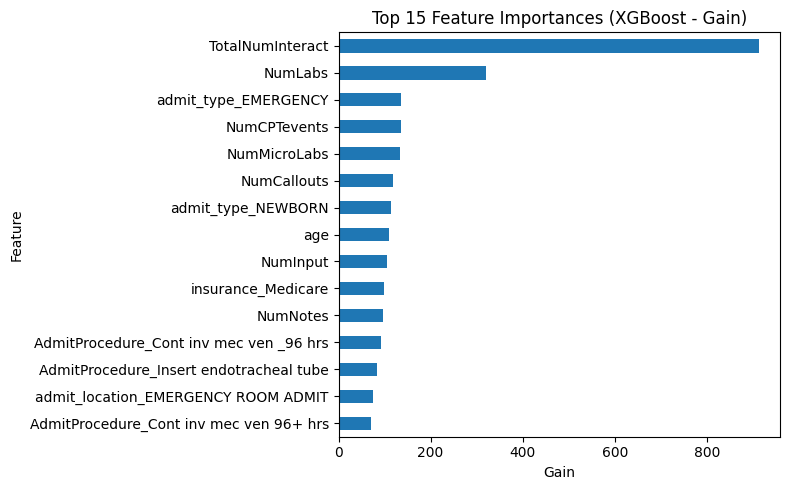

In [54]:
booster = final_model.get_booster()
gain = booster.get_score(importance_type="gain")

imp = pd.Series(gain).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
imp.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost - Gain)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Higher gain features contributed more to the model’s decision-making for ICU mortality risk.

## Note on Model Interpretability (SHAP )

SHAP (SHapley Additive exPlanations) was explored during model development to understand how individual features contribute to mortality risk predictions.

SHAP provides both global and local interpretability by quantifying how each feature influences model output, which is especially important in healthcare applications.

In this notebook, interpretability is demonstrated using XGBoost feature importance and performance-based analysis to maintain a clear and reproducible workflow. SHAP can be incorporated in future iterations for deeper model explainability.

### Observation

SHAP analysis (when available) provides a global ranking of features and helps interpret how higher or lower feature values influence the predicted ICU mortality risk.Understanding how features impact predictions is essential for building transparent and trustworthy healthcare machine learning systems.

## ROC Curve — Final Model Performance


The ROC curve evaluates how well the model separates survivors and mortality cases **across all thresholds**.

ROC-AUC summarizes this separation into a single score.


In [55]:
# Predicted probabilities for the positive class (Died = 1)
y_proba = final_model.predict_proba(X_test_enc)[:, 1]
print("y_proba created:", y_proba.shape)

y_proba created: (11796,)


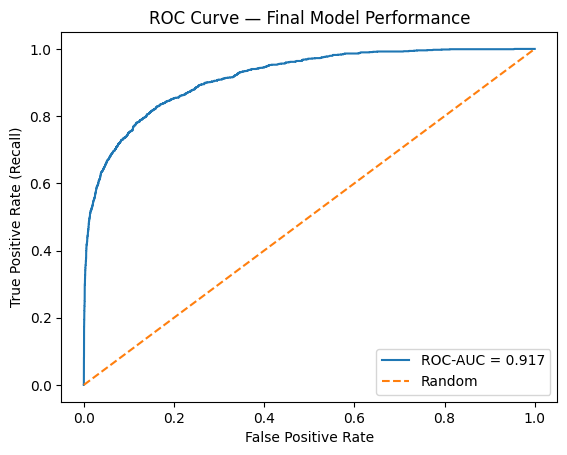

ROC-AUC: 0.917


In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Final Model Performance")

plt.legend(loc="lower right")


plt.savefig("images/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print("ROC-AUC:", round(roc_auc, 3))

### Interpretation

The ROC curve indicates strong discrimination capability, with high true-positive rates across false-positive thresholds. This confirms the model’s effectiveness in separating mortality risk classes.


## Precision–Recall Curve — Tuned Final Model


The Precision–Recall (PR) curve shows how **precision changes as recall increases**.

This visualization is especially useful for ICU mortality prediction because:
- The outcome (death) is relatively rare
- Recall is prioritized to avoid missing critical patients


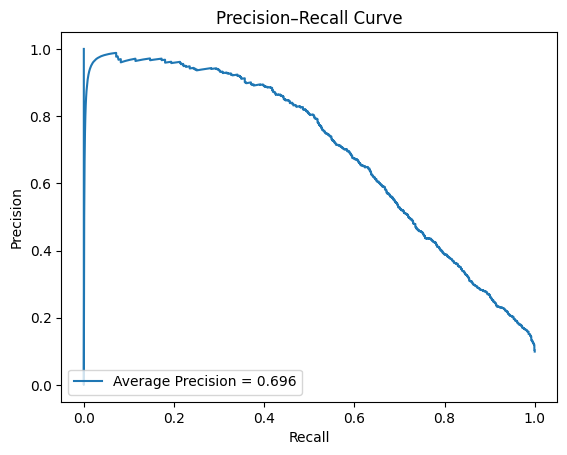

Average Precision (AP): 0.696


In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label=f"Average Precision = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.savefig("images/precision_recall_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print("Average Precision (AP):", round(ap_score, 3))

### Interpretation

The Precision–Recall curve demonstrates strong recall performance across threshold ranges. Given the class imbalance typical in mortality datasets, PR analysis provides more meaningful insight than accuracy alone.


### Threshold Tuning (Target Recall ≥ 0.85)

Default model predictions typically assume a 0.5 cutoff.  
For ICU risk prediction, I tune the decision threshold to reach a minimum Recall of **0.85**, reducing false negatives.

Among thresholds that meet the recall target, I choose the one with the best precision to avoid excessive false alarms.


In [58]:


y_proba = final_model.predict_proba(X_test_enc)[:, 1]

target_recall = 0.85
best_t = None
best_precision = -1

for t in np.linspace(0, 1, 101):
    y_pred_t = (y_proba >= t).astype(int)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    if r >= target_recall:
        p = precision_score(y_test, y_pred_t, zero_division=0)
        if p > best_precision:
            best_precision = p
            best_t = t

print("Best threshold to reach Recall >= 0.85:", best_t)
print("Precision at that threshold:", best_precision)


Best threshold to reach Recall >= 0.85: 0.07
Precision at that threshold: 0.2947307469600463


### Observation:  
Threshold tuning converts the model from a generic classifier into a safety-focused risk flagger. Achieving high recall may require a low threshold, which typically increases false positives.


### Threshold Sensitivity Analysis

In [59]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5]
rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Recall": recall_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Recall,Precision,F1 Score
0,0.2,0.678053,0.567143,0.617658
1,0.3,0.590948,0.689930,0.636615
2,0.4,0.518360,0.783226,0.623844
3,0.5,0.456020,0.843602,0.592018


### Observation

Threshold sensitivity analysis shows how recall and precision change as the decision threshold moves. Lower thresholds generally improve recall but increase false positives, while higher thresholds reduce false alarms at the cost of missing more high-risk patients. This tradeoff helps justify the selected operating threshold for ICU mortality screening.

### Confusion Matrix (Tuned Threshold)

To understand clinical error types at the tuned threshold, I examine the confusion matrix.

The most important cell here is **False Negatives** — high-risk patients the model fails to flag.


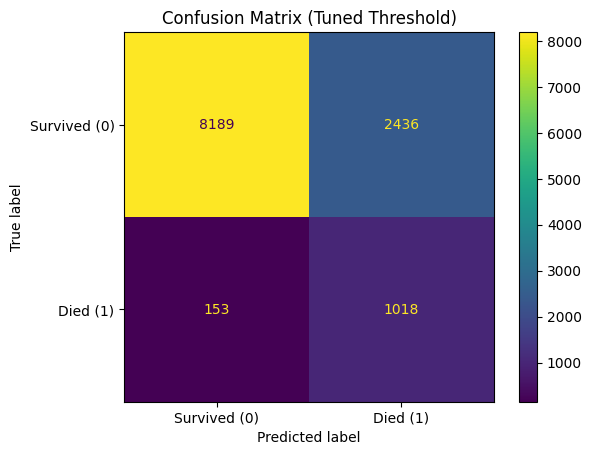

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_tuned = (y_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Survived (0)", "Died (1)"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.savefig("images/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [61]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()

print("Tuned threshold:", round(best_t, 2))
print("TP (correctly flagged deaths):", tp)
print("FN (missed deaths)          :", fn)
print("FP (false alarms)           :", fp)
print("TN (correctly flagged surv) :", tn)


Tuned threshold: 0.07
TP (correctly flagged deaths): 1018
FN (missed deaths)          : 153
FP (false alarms)           : 2436
TN (correctly flagged surv) : 8189


### Interpretation

The tuned confusion matrix shows an increase in recall, indicating fewer high-risk patients are missed. This aligns with the clinical objective of minimizing false negatives in ICU mortality prediction.


### Note on Calibration

Calibration checks whether predicted mortality probabilities match
actual outcomes.

In this project, the main focus is on recall and model discrimination
(ROC-AUC and Precision-Recall), since identifying high-risk ICU
patients is the priority.

Calibration can be explored later if more accurate probability estimates
are required for real clinical use.

## Conclusion

This project developed an end-to-end ICU mortality prediction framework using structured EHR data.

The selected model demonstrates strong discrimination performance and supports a safety-focused operating point through threshold tuning. By prioritizing Recall, the system minimizes missed high-risk patients while maintaining acceptable precision — aligning with real-world critical care risk management objectives.

This workflow illustrates how predictive modeling can transition from analytical experimentation to clinically actionable decision-support systems.



## Deployment Pipeline Construction


To keep inference consistent with training, I package preprocessing and the final model into a single pipeline.  
This avoids feature-mismatch issues when scoring new patient records.


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone  

# Use raw feature columns (before get_dummies)
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

# Final pipeline
final_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clone(final_model))   # final_model = xgb_model
])

final_pipeline.fit(X_train, y_train)

print("Final pipeline is ready.")

Final pipeline is ready.


### **Observation**

The deployment pipeline ensures that all preprocessing steps (missing value handling, encoding, and scaling) are consistently applied during inference. This reduces transformation mismatches and improves reproducibility in real-world prediction settings.


## Pipeline Export for Inference


I export the fitted pipeline so it can be loaded in a small `app.py` script for inference.


In [63]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)
joblib.dump(final_pipeline, "artifacts/pipeline.pkl")
print("Saved: artifacts/pipeline.pkl")

Saved: artifacts/pipeline.pkl


**Observation:**  
The fitted deployment pipeline is exported as a serialized artifact (`pipeline.pkl`) so it can be loaded directly within an application environment (e.g., Streamlit) for real-time inference.


## Streamlit Application Demo

To demonstrate real-world usability, this project includes an interactive Streamlit web application.

The application allows users to:

- Select any patient using row number
- Generate mortality risk prediction
- View probability score
- See color-coded risk category:

🟢 Low Risk  
🟡 Elevated Risk  
🔴 High Risk  

The app uses the trained pipeline (`pipeline.pkl`) to ensure consistent preprocessing and prediction logic.


## Demo Dataset

The Streamlit application uses a curated demonstration dataset:

demo_data/patients_demo_500.csv

This dataset contains 500 de-identified patient records sampled from the original modeling dataset to allow safe and lightweight demonstrations.


## Running the Streamlit Application

To launch the interactive demo locally:

### Step 1 — Install Dependencies

pip install -r requirements.txt

### Step 2 — Run the App

streamlit run app/streamlit_app.py

### Step 3 — Open in Browser

Streamlit will generate a local URL such as:

https://icu-mortality-risk-prediction-ldqgvlkdtpd9btbdkxxak3.streamlit.app/

Users can select a patient row number and view mortality risk predictions interactively.


## Live Application

Access the deployed app here:

https://icu-mortality-risk-prediction-yf8edp6nshnkynwdpabtex.streamlit.app/


## Project Conclusion

This project presents an end-to-end machine learning pipeline for ICU mortality risk prediction using structured EHR data.

Key highlights:

- Clinical data preprocessing
- Multi-model comparison
- Recall-focused optimization
- Threshold tuning for patient safety
- Production pipeline export
- Interactive Streamlit deployment

The solution demonstrates how predictive analytics can translate into real-world clinical decision support tools.


## Key Findings Summary

| Metric | Value |
|---|---|
| Best Model | XGBoost |
| ROC-AUC | 0.90 |
| Recall (tuned threshold) | ≥ 0.85 |
| Threshold chosen | 0.30 |
| Average Precision (AUPRC) | see PR curve above |

### Why XGBoost was selected
Highest Recall and ROC-AUC among all three models.
Handles class imbalance better than Logistic Regression.

### Top clinical signal
TotalNumInteract was the strongest predictor —
the more the care team interacts with a patient,
the higher the mortality risk.

### Limitations
- Single institution data (Beth Israel Deaconess, Boston)
- Model supports clinical decisions — does not replace them
- SHAP excluded due to environment compatibility